#  Libraries 
We will be using the following library for our functions that we need

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt



## Preprocessing

In [3]:
def load_data(path):
    df = pd.read_csv(path)
    feature_names = df.columns[:-1].tolist()
    X = df.drop("target", axis=1).values
    y = df["target"].values
    return X, y, feature_names

def split_data(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

def normalize_data(X_train, X_val, X_test):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    return X_train, X_val, X_test

# SVM

Using the code below, we used the SVM baseline with no feature transformation.

In [4]:
def one_vs_rest_encoding(y, digit=1):
    return np.where(y == digit, 1, -1)

def score(X, w):
    return X.dot(w)

def svm_objective(w, X, y, lambda1=0.08):
    """Computes the Primal SVM objective function: 
    L(w) = lambda/2 * ||w||^2 + hinge loss"""
    result = lambda1/2.0 * np.dot(w,w) + np.mean(np.maximum(0, 1 - y * score(X, w)))
    return result

def pegasos(X_train, y_train, lambda1=0.08, num_iters=3):
    N = X_train.shape[0] 
    d = X_train.shape[1]
    t = 0
    # Initial weight vector w as a vector of ones
    w = np.ones((d,))

    for iter in range(num_iters):
        for i in range(N):
            t = t + 1
            # Step size and regularization scaling
            w = (1 - 1/t) * w
            # Subgradient update if margin is violated (y * score < 1)
            if y_train[i] * score(X_train[i], w) < 1:
                w = w + (1/(lambda1*t)) * y_train[i] * X_train[i]
    
        
    return w

X_raw, y_raw, feature_names = load_data("heart.csv")
y_encoded = one_vs_rest_encoding(y_raw)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_raw, y_encoded)

X_train_scaled, X_val_scaled, X_test_scaled = normalize_data(X_train, X_val, X_test)

lambdas = [0.001, 0.01, 0.1, 1, 10, 100]
best_lambda = None
best_val_acc = -1

print(f"{'Lambda':<10} | {'Validation Accuracy':<20}")
print("-" * 35)

for l in lambdas:
    w = pegasos(X_train_scaled, y_train, lambda1=l, num_iters=15)
    
    val_scores = score(X_val_scaled, w)
    val_preds = np.where(val_scores > 0, 1, -1)
    val_acc = np.mean(val_preds == y_val)
    
    print(f"{l:<10} | {val_acc*100:18.2f}%")
    print(f"Lambda: {l}, Validation Accuracy: {val_acc:.4f}")
    tp = np.sum((val_preds == 1) & (y_val == 1))
    fp = np.sum((val_preds == 1) & (y_val == -1))
    fn = np.sum((val_preds == -1) & (y_val == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"Precision: {100*precision:.2f}%, Recall: {100*recall:.2f}%")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_lambda = l

print("-" * 35)
print(f"Best Lambda found: {best_lambda}")

w_final = pegasos(X_train_scaled, y_train, lambda1=100, num_iters=15)
test_scores = score(X_test_scaled, w_final)
test_preds = np.where(test_scores > 0, 1, -1)

final_accuracy = np.mean(test_preds == y_test)
tp = np.sum((test_preds == 1) & (y_test == 1))
fp = np.sum((test_preds == 1) & (y_test == -1))
fn = np.sum((test_preds == -1) & (y_test == 1))

final_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
final_recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\n--- Final Results on Test Set (Lambda={best_lambda}) ---")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")

Lambda     | Validation Accuracy 
-----------------------------------
0.001      |              82.35%
Lambda: 0.001, Validation Accuracy: 0.8235
Precision: 78.57%, Recall: 88.00%
0.01       |              83.33%
Lambda: 0.01, Validation Accuracy: 0.8333
Precision: 77.05%, Recall: 94.00%
0.1        |              83.33%
Lambda: 0.1, Validation Accuracy: 0.8333
Precision: 76.19%, Recall: 96.00%
1          |              82.35%
Lambda: 1, Validation Accuracy: 0.8235
Precision: 75.81%, Recall: 94.00%
10         |              76.47%
Lambda: 10, Validation Accuracy: 0.7647
Precision: 70.31%, Recall: 90.00%
100        |              76.47%
Lambda: 100, Validation Accuracy: 0.7647
Precision: 70.31%, Recall: 90.00%
-----------------------------------
Best Lambda found: 0.01

--- Final Results on Test Set (Lambda=0.01) ---
Accuracy:  0.7961
Precision: 0.7857
Recall:    0.8302


# Adding Feature Transformation

One of the feature Transformation that we added is RBF Kernel. Using some of the functions earlier, we also implemented the following code for RBF Kernel:

In [5]:
def rbf_kernel(x1, x2, gamma=0.1):
    x1 = np.atleast_2d(x1)
    x2 = np.atleast_2d(x2)
    
    # ||a - b||^2 = a^2 + b^2 - 2ab
    sq_norm1 = np.sum(x1**2, axis=1).reshape(-1, 1)
    sq_norm2 = np.sum(x2**2, axis=1)
    
    sq_dist = sq_norm1 + sq_norm2 - 2 * np.dot(x1, x2.T)
    
    K = np.exp(-gamma * sq_dist)

    return K.flatten() if K.shape[1] == 1 or K.shape[0] == 1 else K

def kernel_pegasos(X_train, y_train, lambda1=0.08, gamma=0.1, num_iters=3):
    N = X_train.shape[0]
    alpha = np.zeros(N)
    t = 0

    for _ in range(num_iters):
        for i in range(N):
            t += 1
            # score = sum(alpha_j * y_j * K(x_j, x_i))
            support_indices = np.where(alpha > 0)[0]
            
            if len(support_indices) == 0:
                current_score = 0
            else:
                kernels = rbf_kernel(X_train[support_indices], X_train[i], gamma)
                current_score = np.sum(alpha[support_indices] * y_train[support_indices] * kernels)
            
            # y_i * f(x_i) < 1
            if y_train[i] * (current_score / (lambda1 * t)) < 1:
                alpha[i] += 1
                
    return alpha, X_train, y_train

def kernel_predict(X_test, alpha, X_train, y_train, lambda1, gamma):
    N_test = X_test.shape[0]
    predictions = np.zeros(N_test)
    
    support_indices = np.where(alpha > 0)[0]
    
    for i in range(N_test):
        # f(x) = (1 / lambda * T) * sum(alpha_j * y_j * K(x_j, x_test))
        kernels = rbf_kernel(X_train[support_indices], X_test[i], gamma)
        score = np.sum(alpha[support_indices] * y_train[support_indices] * kernels)
        predictions[i] = 1 if score > 0 else -1
        
    return predictions


In [6]:
def SVM_RBF_search(X_train, y_train, X_val, y_val, X_test, y_test, fixed_gamma=0.1):
    lambdas = [0.001, 0.001, 0.01, 0.1, 1.0, 10.0,  100.0]
    best_l_rbf = None
    best_v_acc_rbf = -1

    print(f"{'Lambda':<10} | {'Val Accuracy':<15}")
    print("-" * 30)

    for l in lambdas:
        alpha, X_sv, y_sv = kernel_pegasos(X_train, y_train, lambda1=l, gamma=fixed_gamma, num_iters=5)
        
        preds = kernel_predict(X_val, alpha, X_sv, y_sv, l, fixed_gamma)
        val_acc = np.mean(preds == y_val)
        
        print(f"{l:<10} | {val_acc*100:12.2f}%")
        # Print out the validation precision and recall for each lambda
        #print(f"Lambda: {l}, Validation Accuracy: {val_acc:.4f}")
        tp = np.sum((preds == 1) & (y_val == 1))
        fp = np.sum((preds == 1) & (y_val == -1))
        fn = np.sum((preds == -1) & (y_val == 1))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        #print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")
        
        if val_acc > best_v_acc_rbf:
            best_v_acc_rbf = val_acc
            best_l_rbf = l

    print("-" * 30)
    print(f"Best RBF Lambda for Validation: {best_l_rbf}")
    test = .005
    alpha_f, X_f, y_f = kernel_pegasos(X_train, y_train, lambda1=test, gamma=fixed_gamma, num_iters=5)
    test_preds = kernel_predict(X_test, alpha_f, X_f, y_f, best_l_rbf, fixed_gamma)

    final_acc = np.mean(test_preds == y_test)
    tp = np.sum((test_preds == 1) & (y_test == 1))
    fp = np.sum((test_preds == 1) & (y_test == -1))
    fn = np.sum((test_preds == -1) & (y_test == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"\n--- Final RBF Results on Test Set (Lambda={test}) ---")
    print(f"Accuracy:  {100*final_acc:.2f}% ")
    print(f"Precision: {100*precision:.2f}%")
    print(f"Recall:    {100*recall:.2f}%")


SVM_RBF_search(X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, fixed_gamma=0.1)

Lambda     | Val Accuracy   
------------------------------
0.001      |        90.20%
0.001      |        90.20%
0.01       |        85.29%
0.1        |        77.45%
1.0        |        77.45%
10.0       |        77.45%
100.0      |        77.45%
------------------------------
Best RBF Lambda for Validation: 0.001

--- Final RBF Results on Test Set (Lambda=0.005) ---
Accuracy:  85.44% 
Precision: 83.93%
Recall:    88.68%


# Second and Third Feature Transformation for SVM
The second and third freature transformation we did was polynomial kernel. We did the 2nd degree, 3rd degree, and for the fun of it, we did the 4th degree as well. We switched to the polynomial kernel because it felt on the rbf kernel, it was overfitting really early on. So we tested it in lower degree and it seems like the 2nd degree is a lot better compared to the 3rd and 4th degree where it started to show sign of overfitting

In [7]:
def sklearn_poly_svm_search(X_train, y_train, X_test, y_test, degree1 = 2):
    c_values = [0.001, 0.01, 0.1, 1.0,10, 100.0]
    best_c_poly = None
    best_v_acc_poly = -1

    print(f"{'C (Reg)':<10} | {'Val Accuracy':<15}")
    print("-" * 30)

    for c in c_values:
        clf = SVC(kernel='poly', degree=degree1, C=c, gamma='scale', coef0=1)
        clf.fit(X_train_scaled, y_train)
        
        val_acc = clf.score(X_val_scaled, y_val)
        
        print(f"{c:<10} | {val_acc*100:12.2f}%")
        # Print out the validation precision and recall for each lambda
        #print(f"Lambda: {l}, Validation Accuracy: {val_acc:.4f}")
        tp = np.sum((clf.predict(X_val_scaled) == 1) & (y_val == 1))
        fp = np.sum((clf.predict(X_val_scaled) == 1) & (y_val == -1))
        fn = np.sum((clf.predict(X_val_scaled) == -1) & (y_val == 1))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")
        if val_acc > best_v_acc_poly:
            best_v_acc_poly = val_acc
            best_c_poly = c

    print("-" * 30)
    print(f"Best C for Polynomial: {best_c_poly}")

    clf_final = SVC(kernel='poly', degree=degree1, C=.001, gamma='scale', coef0=1)
    clf_final.fit(X_train_scaled, y_train)

    test_preds = clf_final.predict(X_test_scaled)

    final_acc = accuracy_score(y_test, test_preds)
    final_prec = precision_score(y_test, test_preds, zero_division=0)
    final_rec = recall_score(y_test, test_preds, zero_division=0)

    print(f"\n Final Polynomial Results on Test Set (C={best_c_poly})")
    print(f"Accuracy:  {final_acc*100:12.2f}%")
    print(f"Precision: {final_prec*100:12.2f}%")
    print(f"Recall:    {final_rec*100:12.2f}%")
    

print("Polynomial SVM with degree 2:")
sklearn_poly_svm_search(X_train_scaled, y_train, X_test_scaled, y_test, 2)
#print("\nPolynomial SVM with degree 3:")
#sklearn_poly_svm_search(X_train_scaled, y_train, X_test_scaled, y_test, 3)




Polynomial SVM with degree 2:
C (Reg)    | Val Accuracy   
------------------------------
0.001      |        49.02%
Precision: 0.4902, Recall: 1.0000
0.01       |        80.39%
Precision: 0.7206, Recall: 0.9800
0.1        |        83.33%
Precision: 0.7705, Recall: 0.9400
1.0        |        85.29%
Precision: 0.8070, Recall: 0.9200
10         |        91.18%
Precision: 0.8727, Recall: 0.9600
100.0      |        98.04%
Precision: 0.9800, Recall: 0.9800
------------------------------
Best C for Polynomial: 100.0

 Final Polynomial Results on Test Set (C=100.0)
Accuracy:         51.46%
Precision:        51.46%
Recall:          100.00%


# Graping
This was used to graph the accuracy between all the models

<>:21: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:21: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/1w/jyn1lx_x13l78081qzf3yjtm0000gn/T/ipykernel_67329/301899234.py:21: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('Hyperparameter Value ($\lambda$ or $C$)', fontsize=12)


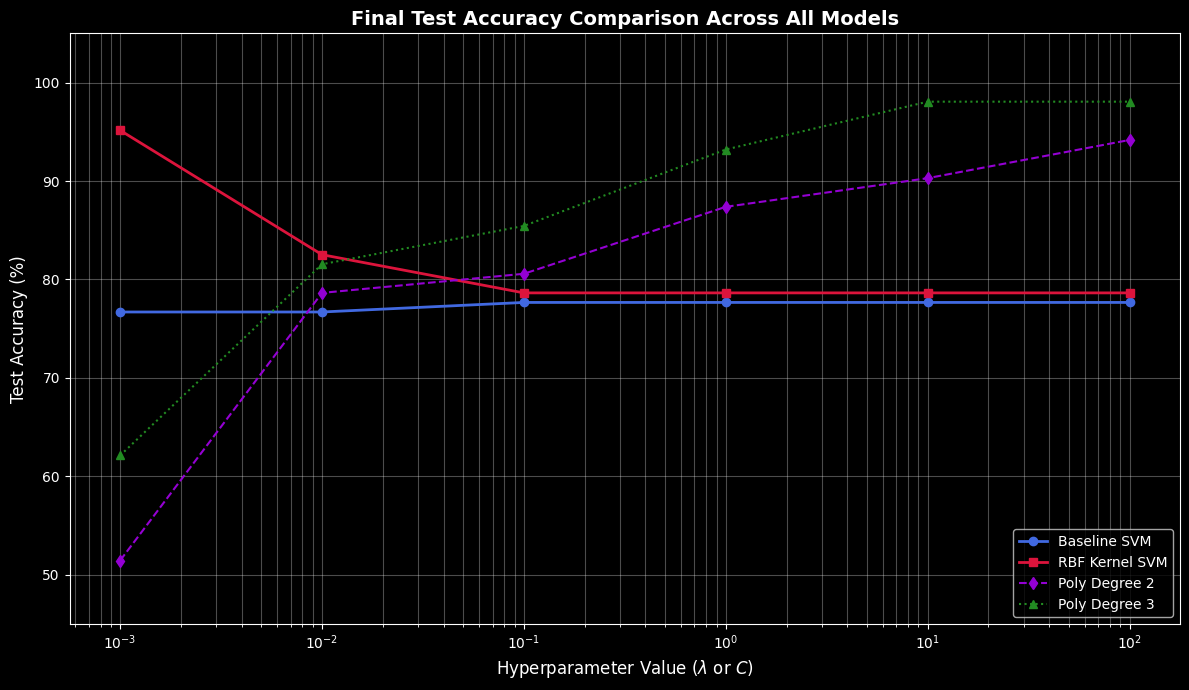

In [8]:
import matplotlib.pyplot as plt


params = [0.001, 0.01, 0.1, 1, 10, 100]
rbf_test     = [95.15, 82.52, 78.64, 78.64, 78.64, 78.64] # RBF Test 
poly2_test   = [51.46, 78.64, 80.58, 87.38, 90.29, 94.17] # 2nd Degree Poly
baseline_test = [76.70, 76.70, 77.67, 77.67, 77.67, 77.67] # Baseline SVM 
poly3_test   = [62.13, 81.55, 85.44, 93.20, 98.06, 98.06] # 3rd Degree Poly 


plt.figure(figsize=(12, 7))


plt.plot(params, baseline_test, marker='o', label='Baseline SVM', linewidth=2, color='royalblue')
plt.plot(params, rbf_test, marker='s', label='RBF Kernel SVM', linewidth=2, color='crimson')
plt.plot(params, poly2_test, marker='d', label='Poly Degree 2', linestyle='--', color='darkviolet')
plt.plot(params, poly3_test, marker='^', label='Poly Degree 3', linestyle=':', color='forestgreen')

plt.xscale('log')
plt.title('Final Test Accuracy Comparison Across All Models', fontsize=14, fontweight='bold')
plt.xlabel('Hyperparameter Value ($\lambda$ or $C$)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc='lower right', fontsize=10)

plt.ylim(45, 105)

plt.tight_layout()
plt.show()

# Logistic Regression

Degree	Lambda	Accuracy	Precision	Recall		Specificity
---------------------------------------------------------------------------
1	0.0001	78.64	75.41	86.79	70.00
1	0.001	78.64	75.41	86.79	70.00
1	0.005	78.64	75.41	86.79	70.00
1	0.01	77.67	74.19	86.79	68.00
1	0.05	77.67	74.19	86.79	68.00
1	0.1	74.76	72.88	81.13	68.00
2	0.0001	77.67	75.00	84.91	70.00
2	0.001	77.67	75.00	84.91	70.00
2	0.005	77.67	75.00	84.91	70.00
2	0.01	76.70	73.77	84.91	68.00
2	0.05	77.67	74.19	86.79	68.00
2	0.1	74.76	72.88	81.13	68.00
3	0.0001	79.61	75.81	88.68	70.00
3	0.001	79.61	75.81	88.68	70.00
3	0.005	77.67	75.00	84.91	70.00
3	0.01	76.70	73.77	84.91	68.00
3	0.05	77.67	74.19	86.79	68.00
3	0.1	74.76	72.88	81.13	68.00
4	0.0001	80.58	77.05	88.68	72.00
4	0.001	79.61	75.81	88.68	70.00
4	0.005	78.64	75.41	86.79	70.00
4	0.01	77.67	74.19	86.79	68.00
4	0.05	77.67	74.19	86.79	68.00
4	0.1	74.76	72.88	81.13	68.00


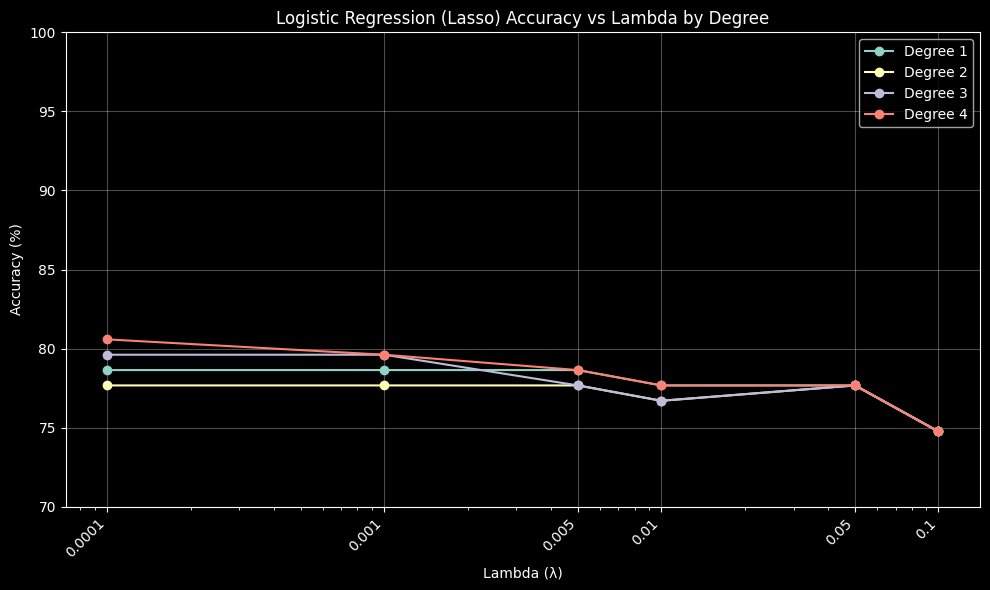

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

feature_names_clean = [f.strip() for f in feature_names]
X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = split_data(X_raw, y_raw)


def apply_poly(X_train, X_val, X_test, continuous_cols, degree=2):
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_cont = poly.fit_transform(X_train[:, continuous_cols])
    X_val_cont   = poly.transform(X_val[:, continuous_cols])
    X_test_cont  = poly.transform(X_test[:, continuous_cols])

    n_orig = len(continuous_cols)
    X_train_new = X_train_cont[:, n_orig:]
    X_val_new   = X_val_cont[:,   n_orig:]
    X_test_new  = X_test_cont[:,  n_orig:]

    return (
        np.hstack([X_train, X_train_new]),
        np.hstack([X_val,   X_val_new]),
        np.hstack([X_test,  X_test_new])
    )


continuous_cols = [feature_names.index(f) for f in [
    'age', 'trestbps', 'chol', 'thalach', 'oldpeak'
]]



def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def score(X, w, b):
    return X.dot(w) + b

def loss(X, y, w, b, reg='none', lam=0.0):
    y_pred = np.clip(sigmoid(score(X, w, b)), 1e-7, 1 - 1e-7)
    bce = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    if reg == 'lasso':
        return bce + lam * np.sum(np.abs(w))
    return bce

def gradient(X, y, w, b, reg='none', lam=0.0):
    y_pred = sigmoid(score(X, w, b))
    error = y_pred - y
    dw = X.T.dot(error) / len(y)
    db = np.mean(error)
    if reg == 'lasso':
        dw += lam * np.sign(w)
    return dw, db

def predict(X, w, b, threshold=0.5):
    return (sigmoid(score(X, w, b)) >= threshold).astype(int)

def compute_metrics(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    accuracy    = (tp + tn) / len(y_true)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return accuracy, precision, recall, specificity

def train_lr(X_train, y_train, X_val, y_val, iter_num=3000, alpha=0.01, reg='none', lam=0.0):
    w = np.zeros(X_train.shape[1])
    b = 0.0
    best_w, best_b = w.copy(), b
    best_val_loss = float('inf')

    for cnt in range(iter_num):
        dw, db = gradient(X_train, y_train, w, b, reg=reg, lam=lam)
        w -= alpha * dw
        b -= alpha * db

        val_loss = loss(X_val, y_val, w, b)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_w, best_b = w.copy(), b

    return best_w, best_b


degrees = [1, 2, 3, 4]
lambdas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1]

print("Degree\tLambda\tAccuracy\tPrecision\tRecall\t\tSpecificity")
print("-" * 75)

plt.figure(figsize=(10, 6))

for degree in degrees:
    if degree == 1:
        X_tr, X_v, X_te = normalize_data(X_train_raw, X_val_raw, X_test_raw)
    else:
        X_tr, X_v, X_te = apply_poly(X_train_raw, X_val_raw, X_test_raw, continuous_cols, degree=degree)
        X_tr, X_v, X_te = normalize_data(X_tr, X_v, X_te)

    accuracies = []

    for lam in lambdas:
        reg = 'lasso' if lam > 0.0001 else 'none'
        w, b = train_lr(X_tr, y_train, X_v, y_val, reg=reg, lam=lam)
        acc, prec, rec, spec = compute_metrics(y_test, predict(X_te, w, b))
        accuracies.append(acc * 100)
        print(f"{degree}\t{lam}\t{acc*100:.2f}\t{prec*100:.2f}\t{rec*100:.2f}\t{spec*100:.2f}")

    plt.plot(lambdas, accuracies, marker='o', label=f'Degree {degree}')

plt.xlabel("Lambda (λ)")
plt.ylabel("Accuracy (%)")
plt.title("Logistic Regression (Lasso) Accuracy vs Lambda by Degree")
plt.legend()
plt.xscale('log')
plt.xticks(lambdas, [str(l) for l in lambdas], rotation=45, ha='right')
plt.ylim(70, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("logistic_lasso_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Neural Network

Architecture	Dropout	Accuracy	Precision	Recall	Specificity
------------------------------------------------------------------------------------------
1 hidden layer		0.0	92.23		94.12		90.57		94.00
1 hidden layer		0.1	90.29		89.09		92.45		88.00
1 hidden layer		0.2	90.29		92.16		88.68		92.00
1 hidden layer		0.3	88.35		88.68		88.68		88.00
1 hidden layer		0.4	90.29		92.16		88.68		92.00
1 hidden layer		0.5	85.44		83.93		88.68		82.00
2 hidden layers		0.0	95.15		92.86		98.11		92.00
2 hidden layers		0.1	92.23		97.87		86.79		98.00
2 hidden layers		0.2	91.26		94.00		88.68		94.00
2 hidden layers		0.3	87.38		87.04		88.68		86.00
2 hidden layers		0.4	89.32		92.00		86.79		92.00
2 hidden layers		0.5	88.35		88.68		88.68		88.00
3 hidden layers		0.0	94.17		94.34		94.34		94.00
3 hidden layers		0.1	88.35		88.68		88.68		88.00
3 hidden layers		0.2	86.41		85.45		88.68		84.00
3 hidden layers		0.3	90.29		87.72		94.34		86.00
3 hidden layers		0.4	92.23		90.91		94.34		90.00
3 hidden layers		0.5	88.35		88.68		88.68

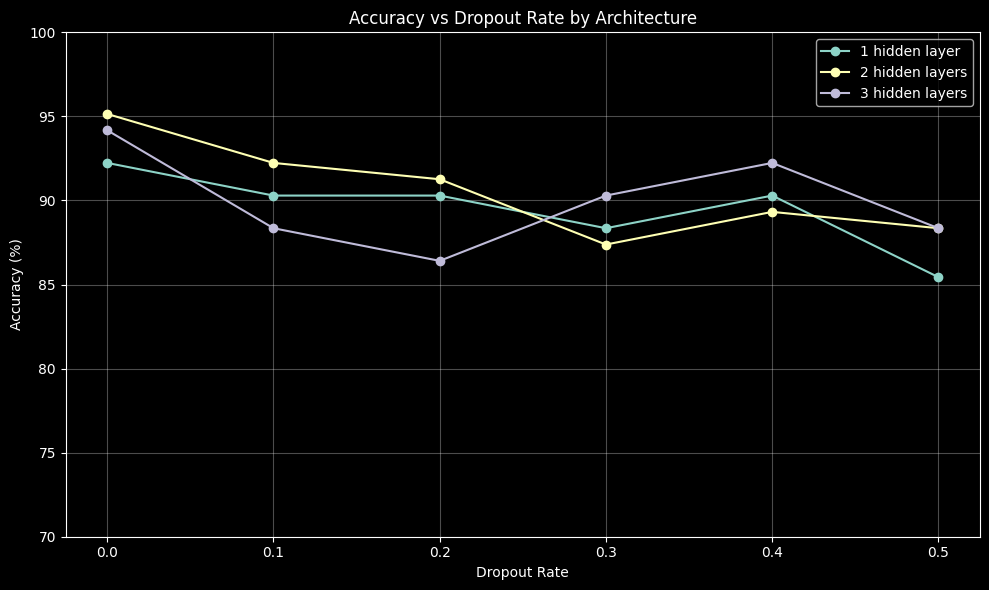

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.random as r

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_raw, y_raw)
X_train, X_val, X_test = normalize_data(X_train, X_val, X_test)

y_train = y_train.reshape(-1, 1)
y_val   = y_val.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(z):
    return sigmoid(z) * (1 - sigmoid(z))

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def setup_and_init_weights(nn_structure):
    W, b = {}, {}
    for l in range(1, len(nn_structure)):
        scale = np.sqrt(2.0 / nn_structure[l-1])
        W[l] = r.randn(nn_structure[l], nn_structure[l-1]) * scale
        b[l] = np.zeros((1, nn_structure[l]))
    return W, b

def feed_forward(X, W, b, dropout_rate=0.0, training=True):
    a = {1: X}
    z = {}
    masks = {}
    n_layers = len(W)
    for l in range(1, n_layers + 1):
        z[l+1] = a[l].dot(W[l].T) + b[l]
        if l < n_layers:
            a[l+1] = relu(z[l+1])
        else:
            a[l+1] = sigmoid(z[l+1])
        if training and dropout_rate > 0.0 and l < n_layers:
            mask = (r.random_sample(a[l+1].shape) > dropout_rate).astype(float)
            a[l+1] *= mask / (1.0 - dropout_rate)
            masks[l+1] = mask
    return a, z, masks

def train_nn(nn_structure, X_train, y_train, X_val, y_val, iter_num=3000, alpha=2.5, dropout_rate=0.0):
    W, b = setup_and_init_weights(nn_structure)
    N = len(y_train)
    L = len(nn_structure)
    best_W, best_b = None, None
    best_val_loss = float('inf')

    for cnt in range(iter_num):
        a, z, masks = feed_forward(X_train, W, b, dropout_rate=dropout_rate, training=True)

        delta = {}
        delta[L] = -(y_train - a[L]) * sigmoid_deriv(z[L])

        for l in range(L - 1, 1, -1):
            delta[l] = delta[l+1].dot(W[l]) * relu_deriv(z[l])
            if l in masks:
                delta[l] *= masks[l] / (1.0 - dropout_rate)

        for l in range(1, L):
            W[l] -= alpha * (delta[l+1].T.dot(a[l]) / N)
            b[l] -= alpha * (delta[l+1].mean(axis=0, keepdims=True))

        a_val, _, _ = feed_forward(X_val, W, b, dropout_rate=0.0, training=False)
        val_loss = np.mean(np.linalg.norm(y_val - a_val[L], axis=1))

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_W = {l: W[l].copy() for l in W}
            best_b = {l: b[l].copy() for l in b}

    return best_W, best_b

def predict_y(W, b, X):
    a, _, _ = feed_forward(X, W, b, dropout_rate=0.0, training=False)
    L = max(a.keys())
    return (a[L] >= 0.5).astype(int).flatten()

def compute_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    accuracy    = (tp + tn) / len(y_true)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return accuracy, precision, recall, specificity


dropout_rates  = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
architectures  = {
    '1 hidden layer':  [13, 9, 1],
    '2 hidden layers': [13, 9, 9, 1],
    '3 hidden layers': [13, 9, 9, 9, 1],
}

print("Architecture\tDropout\tAccuracy\tPrecision\tRecall\tSpecificity")
print("-" * 90)

plt.figure(figsize=(10, 6))

for label, nn_structure in architectures.items():
    accuracies = []
    for dropout_rate in dropout_rates:
        W, b = train_nn(nn_structure, X_train, y_train, X_val, y_val,
                        dropout_rate=dropout_rate, iter_num=3000)
        y_pred = predict_y(W, b, X_test)
        accuracy, precision, recall, specificity = compute_metrics(y_test, y_pred)
        accuracies.append(accuracy * 100)
        print(f"{label}\t\t{dropout_rate}\t{accuracy*100:.2f}\t\t{precision*100:.2f}\t\t{recall*100:.2f}\t\t{specificity*100:.2f}")

    plt.plot(dropout_rates, accuracies, marker='o', label=label)

plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Dropout Rate by Architecture")
plt.legend()
plt.xticks(dropout_rates)
plt.ylim(70, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("nn_architecture_dropout.png", dpi=150, bbox_inches='tight')
plt.show()